In [10]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def plot_lattice(ax):
    elements = [
        ("drift", 0.260),
        ("coll", 0.0025),
        ("drift", 0.3375),
        ("dipole", 0.628318),
        ("drift", 0.208),
        ("chopper", 0.150),
        ("drift", 0.140),
        ("drift", 0.722),
        ("collx", 0.002),
        ("drift", 0.002),
        ("colly", 0.002),
        ("drift", 0.194),
        ("quad", 0.140),
        ("drift", 0.092),
        ("quad", 0.140),
        ("drift", 0.092),
        ("quad", 0.140),
        ("drift", 0.9101),
        ("solenoid", 0.2574),
        ("drift", 0.1393),
    ]

    y_min, y_max = ax.get_ylim()

    height = 0.15 * (y_max - y_min)
    y0 = -height / 2  

    s_pos = 0

    for name, length in elements:
        s0 = s_pos
        s1 = s_pos + length

        if name == "dipole":
            color = "black"
            alpha = 0.25

        elif name == "quad":
            color = "black"
            alpha = 0.9

        elif name == "solenoid":
            color = "black"
            alpha = 0.5

        elif name.startswith("coll"):
            color = "gray"
            alpha = 0.6

        elif name == "chopper":
            color = "purple"
            alpha = 0.5

        else:
            s_pos = s1
            continue

        rect = plt.Rectangle(
            (s0, y0),
            s1 - s0,
            height,
            color=color,
            alpha=alpha
        )

        ax.add_patch(rect)

        s_pos = s1

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Parser

In [11]:
datos = np.loadtxt("lebt.stat", skiprows=303)

s = datos[:, 1]
num_particles = datos[:, 2]
rms_x = datos[:, 5]      # m
rms_y = datos[:, 6]      # m
rms_px = datos[:, 8]     # normalized momentum in x
rms_py = datos[:, 9]     # normalized momentum in y
rms_ps = datos[:, 10]    # normalized momentum in z
emit_x = datos[:, 11]    # normalized emittance
emit_y = datos[:, 12]    # normalized emittance
ref_px = datos[:, 20]    # reference normalized momentum in x
ref_py = datos[:, 21]    # reference normalized momentum in y
ref_pz = datos[:, 22]    # reference normalized momentum in z
energy = datos[:, 4]

data_monitor = np.loadtxt("M1.loss", skiprows=1)
m1_x = data_monitor[:, 0]
m1_y = data_monitor[:, 1]
m1_xp = data_monitor[:, 3]/data_monitor[:,5 ]
m1_yp = data_monitor[:, 4]/data_monitor[:,5 ]



# Input Point
s_input = s[0]

sigma_x_opal_input = rms_x[0] * 1e3   # m -> mm
sigma_y_opal_input = rms_y[0] * 1e3   # m -> mm

p_ref_input = np.sqrt(ref_px[0]**2 + ref_py[0]**2 + ref_pz[0]**2)

# x' ≈ px / |p|, y' ≈ py / |p|
sigma_xp_opal_input = (rms_px[0] / p_ref_input) * 1e3   # rad -> mrad
sigma_yp_opal_input = (rms_py[0] / p_ref_input) * 1e3   # rad -> mrad

emit_x_opal_input = emit_x[0] * 1e6   # m rad -> mm mrad
emit_y_opal_input = emit_y[0] * 1e6   # m rad -> mm mrad

print("OPAL input values")
print("-----------------")
print(f"Beam horizontal rms-size        sigma_x  = {sigma_x_opal_input:.6f} mm")
print(f"Beam vertical rms-size          sigma_y  = {sigma_y_opal_input:.6f} mm")
print(f"Beam horizontal rms-divergence  sigma_x' = {sigma_xp_opal_input:.6f} mrad")
print(f"Beam vertical rms-divergence    sigma_y' = {sigma_yp_opal_input:.6f} mrad")
print(f"Beam horizontal normalized emittance: emit_x = {emit_x_opal_input:.6f} mm mrad")
print(f"Beam vertical normalized emittance:   emit_y = {emit_y_opal_input:.6f} mm mrad")

print()

# ------------------------------------------------------------
# Final point
# ------------------------------------------------------------
s_final = s[-1]

sigma_x_opal = rms_x[-1] * 1e3   # m 2 mm
sigma_y_opal = rms_y[-1] * 1e3   # m 2 mm

p_ref = np.sqrt(ref_px[-1]**2 + ref_py[-1]**2 + ref_pz[-1]**2)

sigma_xp_opal = (rms_px[-1] / p_ref) * 1e3   # rad 2 mrad
sigma_yp_opal = (rms_py[-1] / p_ref) * 1e3   # rad 2 mrad

emit_x_opal = emit_x[-1]  * 1e6  # m rad 2 mm mrad
emit_y_opal = emit_y[-1]  * 1e6  # m rad 2 mm mrad

print("OPAL final values")
print("-----------------")
print(f"Beam horizontal rms-size        sigma_x  = {sigma_x_opal:.6f} mm")
print(f"Beam vertical rms-size          sigma_y  = {sigma_y_opal:.6f} mm")
print(f"Beam horizontal rms-divergence  sigma_x' = {sigma_xp_opal:.6f} mrad")
print(f"Beam vertical rms-divergence    sigma_y' = {sigma_yp_opal:.6f} mrad")
print(f"Beam horizontal normalized emittance: emit_x = {emit_x_opal:.6f} mm mrad")
print(f"Beam vertical normalized emittance:   emit_y = {emit_y_opal:.6f} mm mrad")

OPAL input values
-----------------
Beam horizontal rms-size        sigma_x  = 3.449651 mm
Beam vertical rms-size          sigma_y  = 3.432770 mm
Beam horizontal rms-divergence  sigma_x' = 7.750802 mrad
Beam vertical rms-divergence    sigma_y' = 7.784310 mrad
Beam horizontal normalized emittance: emit_x = 0.152838 mm mrad
Beam vertical normalized emittance:   emit_y = 0.152758 mm mrad

OPAL final values
-----------------
Beam horizontal rms-size        sigma_x  = 5.884842 mm
Beam vertical rms-size          sigma_y  = 6.711256 mm
Beam horizontal rms-divergence  sigma_x' = 3.139093 mrad
Beam vertical rms-divergence    sigma_y' = 4.183385 mrad
Beam horizontal normalized emittance: emit_x = 0.097723 mm mrad
Beam vertical normalized emittance:   emit_y = 0.153191 mm mrad


## Plots

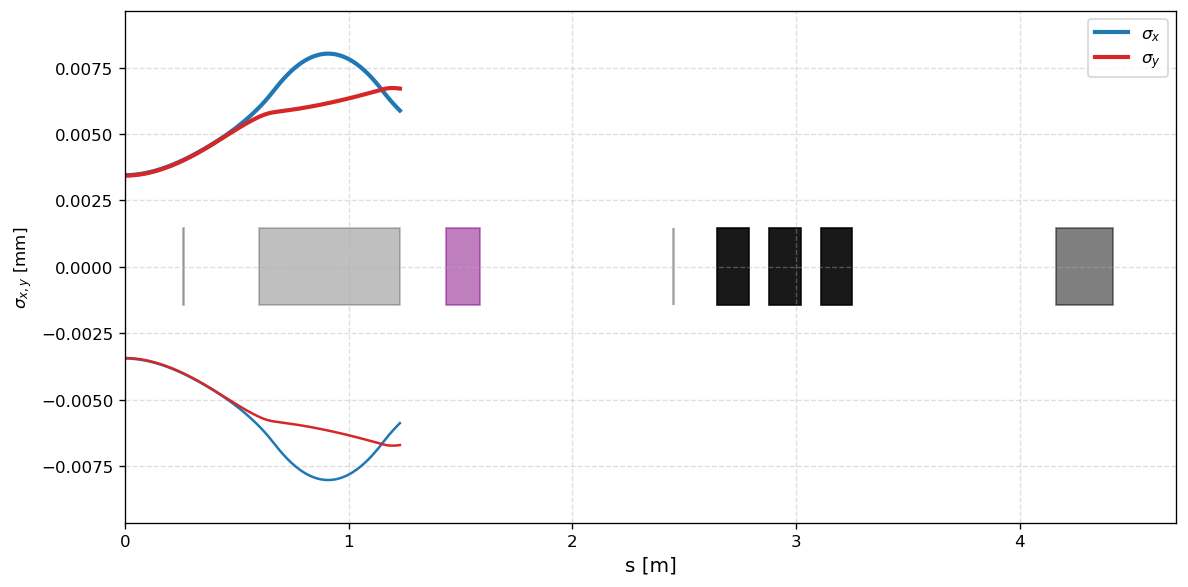

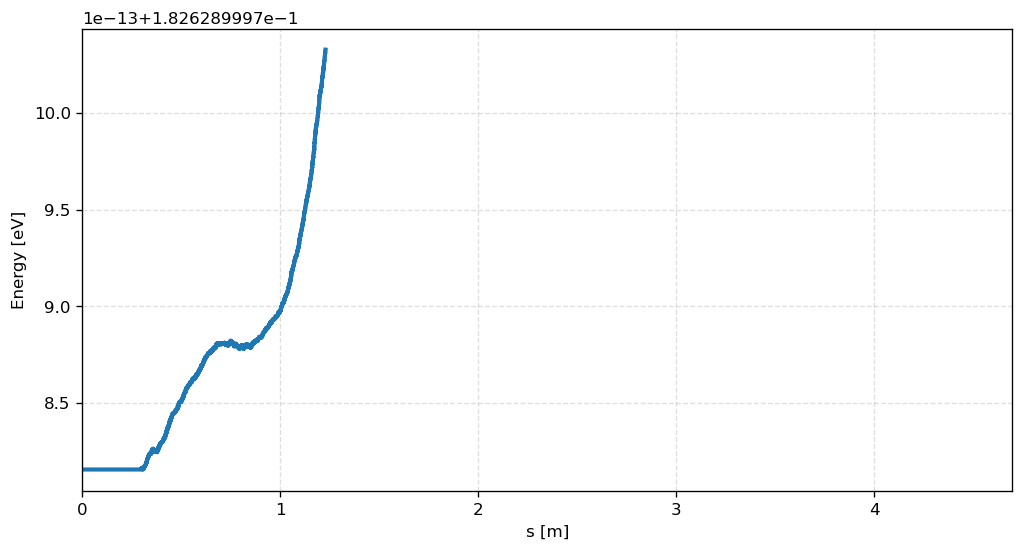

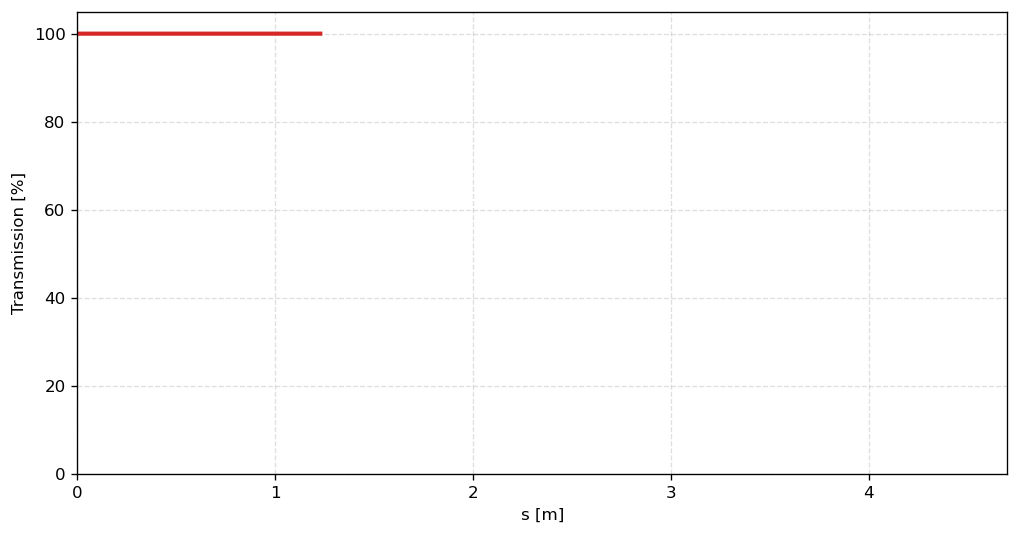

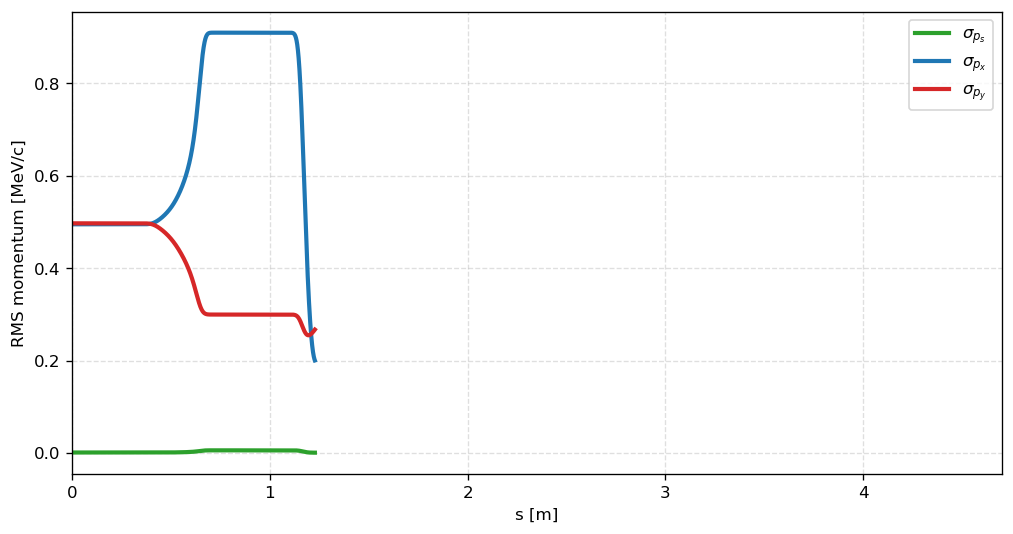

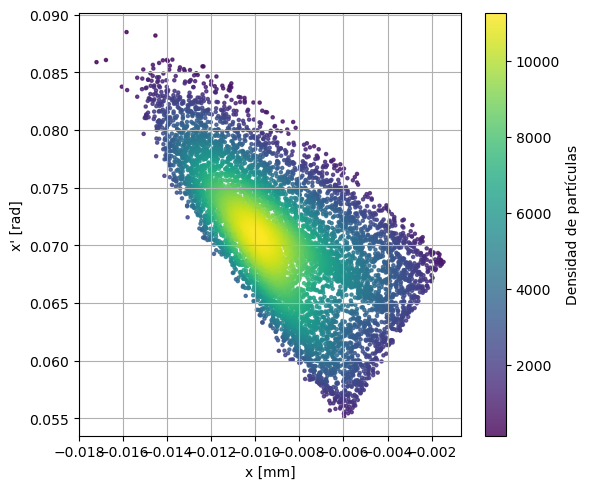

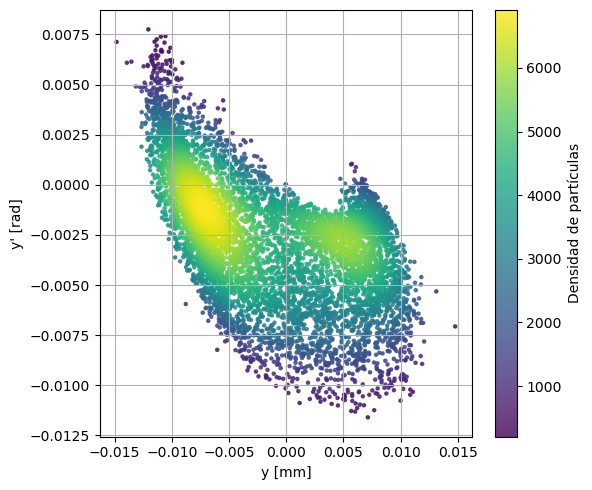

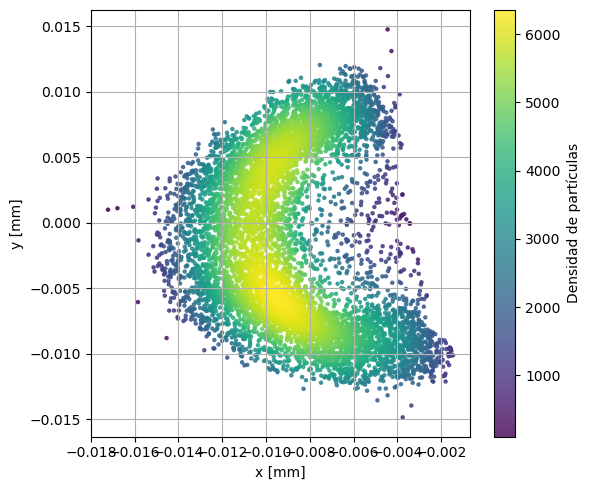

In [12]:
import sys

root = Path.cwd().resolve().parent
results_dir = root / "beam_plots"
rftrack_dir = root / "rftrack"

results_dir.mkdir(parents=True, exist_ok=True)

sys.path.append(str(rftrack_dir))

from aux import plot_phase_space

fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
color_x = 'tab:blue'
color_y = 'tab:red'
ax.plot(s,  rms_x, color=color_x,linewidth=2.5, label=r'$\sigma_x$')
ax.plot(s, -rms_x, color=color_x,linewidth=1.5)
ax.plot(s,  rms_y, color=color_y, linewidth=2.5, label=r'$\sigma_y$')
ax.plot(s, -rms_y, color=color_y, linewidth=1.5)
ax.set_xlabel('s [m]',fontsize=12)
ax.set_ylabel(r'$\sigma_{x,y}$ [mm]')
ax.set_xlim(0, 4.7)
ax.set_ylim(-max(rms_x)*1.2, max(rms_x)*1.2)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plot_lattice(ax)
fig.savefig(results_dir / "opal_lebt_lattice.png", bbox_inches="tight")
plt.show()

# Energy plot
plt.figure(figsize=(10, 5), dpi=120)
plt.plot(s, energy, color="tab:blue", linewidth=2.5)
plt.xlabel('s [m]')
plt.ylabel('Energy [eV]')
plt.xlim(0, 4.7)
plt.grid(True, linestyle='--', alpha=0.4)
plt.savefig(results_dir / "opal_lebt_energy.png", bbox_inches="tight")
plt.show()

# transmission plot
plt.figure(figsize=(10, 5), dpi=120)
plt.plot(s, num_particles/num_particles[0]*100, color="tab:red",linewidth=2.5)
plt.xlabel('s [m]')
plt.ylabel('Transmission [%]')
plt.xlim(0, 4.7) 
plt.ylim(0, 105)
plt.grid(True, linestyle='--', alpha=0.4)
plt.savefig(results_dir / "opal_lebt_transmission.png", bbox_inches="tight")
plt.show()

# momentum RMS plot

m_c12_6 = 11.9967074084982  # amu
amu = 931.49410372          # MeV/c^2
mass = m_c12_6 * amu        # MeV/c^2

plt.figure(figsize=(10, 5), dpi=120)
plt.plot(s, rms_ps*mass, color="tab:green", linewidth=2.5, label=r'$\sigma_{p_s}$')
plt.plot(s, rms_px*mass, color="tab:blue", linewidth=2.5, label=r'$\sigma_{p_x}$')
plt.plot(s, rms_py*mass, color="tab:red", linewidth=2.5, label=r'$\sigma_{p_y}$')

plt.xlabel('s [m]')
plt.ylabel(r'RMS momentum [MeV/c]')
plt.xlim(0, 4.7)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.savefig(results_dir / "opal_lebt_momentum_RMS_MeVc.png", bbox_inches="tight")
plt.show()

# Phase space plots

plot_phase_space(m1_x, m1_xp, "x [mm]", "x' [rad]")
plot_phase_space(m1_y, m1_yp, "y [mm]", "y' [rad]")
plot_phase_space(m1_x, m1_y,  "x [mm]", "y [mm]")

In [13]:
import pandas as pd

positions = [
    ("LEBT input",        0.000000),

    ("Before dipole",    0.600000),
    ("After dipole",     1.228318),

    ("Before QUAD1",     2.648318),
    ("After QUAD1",      2.788318),

    ("Before QUAD2",     2.880318),
    ("After QUAD2",      3.020318),

    ("Before QUAD3",     3.112318),
    ("After QUAD3",      3.252318),

    ("Before solenoid",  4.162418),
    ("After solenoid",   4.419818),

    ("LEBT output",      s[-1]),
]

def nearest_index(s_array, s_target):
    return int(np.argmin(np.abs(s_array - s_target)))

def opal_values_at(i):
    p_ref = np.sqrt(ref_px[i]**2 + ref_py[i]**2 + ref_pz[i]**2)

    sigma_x = rms_x[i] * 1e3
    sigma_y = rms_y[i] * 1e3

    sigma_xp = (rms_px[i] / p_ref) * 1e3
    sigma_yp = (rms_py[i] / p_ref) * 1e3

    emit_x_norm = emit_x[i] * 1e6
    emit_y_norm = emit_y[i] * 1e6

    return sigma_x, sigma_y, sigma_xp, sigma_yp, emit_x_norm, emit_y_norm


rows = []
N0 = num_particles[0]

for name, s_target in positions:
    i = nearest_index(s, s_target)

    (
        sigma_x,
        sigma_y,
        sigma_xp,
        sigma_yp,
        emit_x_norm,
        emit_y_norm,
    ) = opal_values_at(i)

    rows.append({
        "Position": name,
        "s target [m]": s_target,
        "s OPAL [m]": s[i],
        "Delta s [mm]": (s[i] - s_target) * 1e3,
        "N particles": num_particles[i],
        "Transmission": num_particles[i] / N0,
        "sigma_x [mm]": sigma_x,
        "sigma_y [mm]": sigma_y,
        "sigma_x' [mrad]": sigma_xp,
        "sigma_y' [mrad]": sigma_yp,
        "emit_x,n [mm mrad]": emit_x_norm,
        "emit_y,n [mm mrad]": emit_y_norm,
    })

opal_sections = pd.DataFrame(rows)

opal_sections

,Position,s target [m],s OPAL [m],Delta s [mm],N particles,Transmission,sigma_x [mm],sigma_y [mm],sigma_x' [mrad],sigma_y' [mrad],"emit_x,n [mm mrad]","emit_y,n [mm mrad]"
0,LEBT input,0.000000,0.000034,0.034279,15673.0,1.0,3.449651,3.432770,7.750802,7.784310,0.152838,0.152758
1,Before dipole,0.600000,0.600014,0.014105,15673.0,1.0,6.014178,5.654186,10.027176,6.059490,0.152374,0.152763
2,After dipole,1.228318,1.228308,-0.009874,15673.0,1.0,5.884842,6.711256,3.139093,4.183385,0.097723,0.153191
3,Before QUAD1,2.648318,1.228308,-1420.009874,15673.0,1.0,5.884842,6.711256,3.139093,4.183385,0.097723,0.153191
4,After QUAD1,2.788318,1.228308,-1560.009874,15673.0,1.0,5.884842,6.711256,3.139093,4.183385,0.097723,0.153191
5,Before QUAD2,2.880318,1.228308,-1652.009874,15673.0,1.0,5.884842,6.711256,3.139093,4.183385,0.097723,0.153191
6,After QUAD2,3.020318,1.228308,-1792.009874,15673.0,1.0,5.884842,6.711256,3.139093,4.183385,0.097723,0.153191
7,Before QUAD3,3.112318,1.228308,-1884.009874,15673.0,1.0,5.884842,6.711256,3.139093,4.183385,0.097723,0.153191
8,After QUAD3,3.252318,1.228308,-2024.009874,15673.0,1.0,5.884842,6.711256,3.139093,4.183385,0.097723,0.153191
9,Before solenoid,4.162418,1.228308,-2934.109874,15673.0,1.0,5.884842,6.711256,3.139093,4.183385,0.097723,0.153191
